# 05 - Análise de série temporal e granularidade

Os notebooks 03 e 04 tratam o problema como aprendizado supervisionado: cada mês vira uma linha com
features do passado. Aqui olhamos o mesmo dado como **série temporal**, que é o que ele é: o preço de
um item observado mês a mês, em que o valor de hoje depende do valor de ontem.

Três perguntas:

1. **Do que é feita cada série?** Tendência, sazonalidade e ruído (decomposição STL), estacionariedade e autocorrelação.
2. **Modelos clássicos de série temporal (SARIMA, Holt-Winters) funcionam aqui?** Como se comparam ao ML?
3. **Qual a granularidade certa?** Mensal, trimestral ou anual; item específico ou agregado.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from src.config import ARQUIVO_PRECOS, ARQUIVO_ITENS, POWERBI_DIR, FIGURES_DIR
from src.features.analise_series import decompor, forcas, adf_pvalor, agregar

pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

precos = pd.read_parquet(ARQUIVO_PRECOS)
itens = pd.read_parquet(ARQUIVO_ITENS)
series_ok = itens.loc[itens["motivo_exclusao"].isna(), "serie_id"].tolist()

def serie(item_inicio):
    sid = itens.loc[itens["item"].str.startswith(item_inicio), "serie_id"].iloc[0]
    return precos[precos["serie_id"] == sid].set_index("data")["preco"].asfreq("MS")

## 1. Granularidade da base

Granularidade é o nível de detalhe de cada observação. Nesta base ela tem três dimensões:

| Dimensão | Nesta base | Mais fino possível? |
|---|---|---|
| Tempo | mensal | não: o BLS só publica preço médio por mês |
| Espaço | média nacional (U.S. city average) | existe por região no BLS, mas não veio no dataset |
| Produto | item específico (ex.: *Ground chuck*) e alguns agregados (*All uncooked ground beef*) | já é o mais fino |

Então dá para **agregar** (mensal para trimestral/anual, itens para categorias), mas não para desagregar.
A seção 5 testa se agregar ajuda ou atrapalha a previsão.

## 2. Componentes da série: tendência, sazonalidade e ruído

A STL separa o log do preço em três partes: **tendência** (movimento de longo prazo), **sazonalidade**
(padrão que se repete a cada 12 meses) e **resto** (o que sobra, o ruído). Usamos log para a
sazonalidade virar percentual (morango 20% mais caro no inverno, não "US$ 0,50 mais caro").

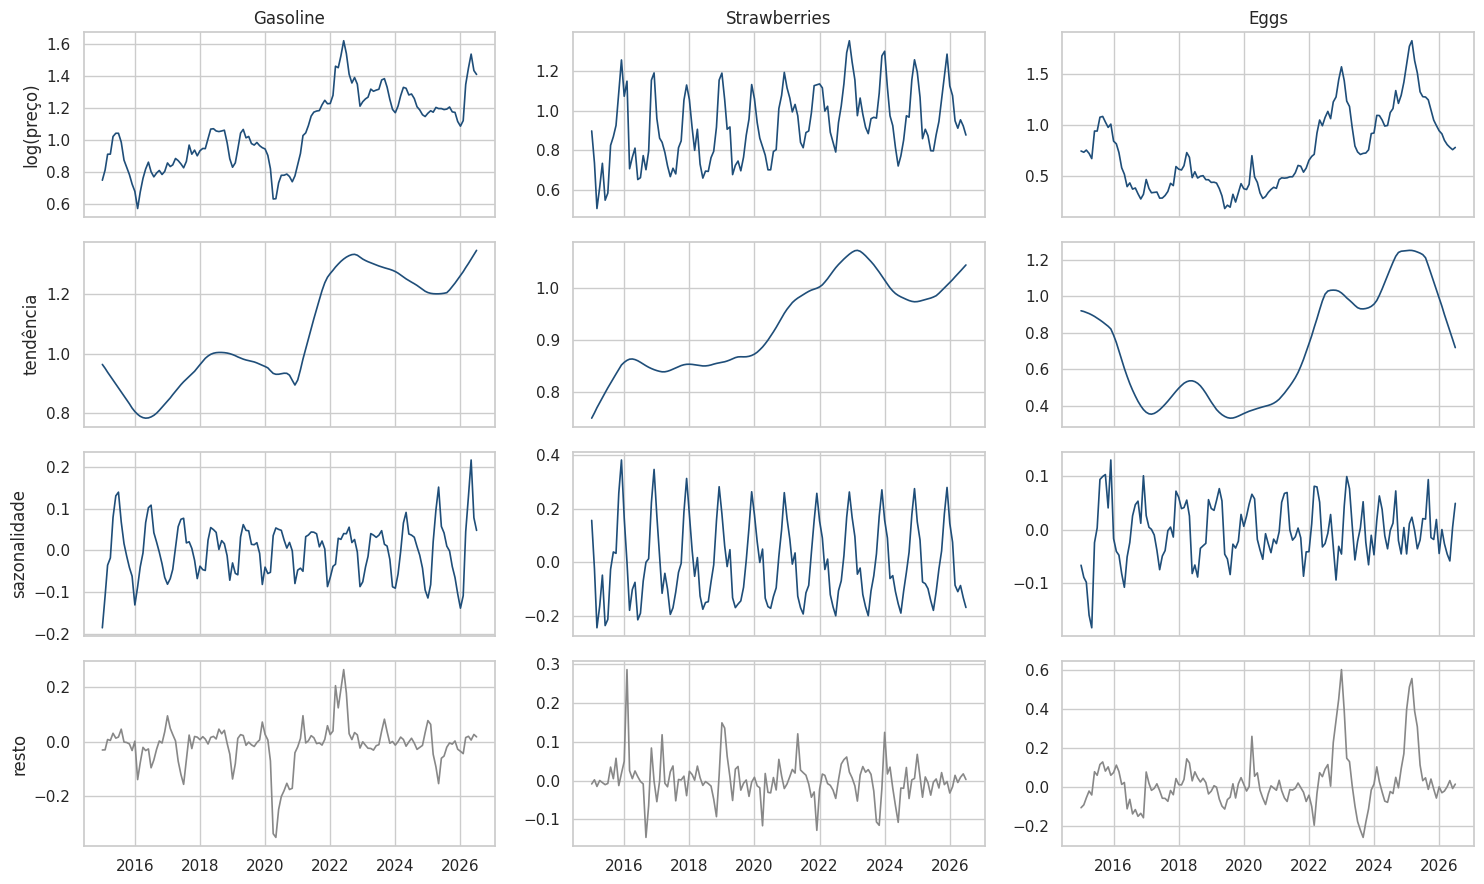

In [2]:
fig, axes = plt.subplots(4, 3, figsize=(15, 9), sharex="col")
for j, nome in enumerate(["Gasoline, unleaded regular", "Strawberries", "Eggs"]):
    d = decompor(serie(nome))
    for i, (comp, rot) in enumerate([(d.observed, "log(preço)"), (d.trend, "tendência"), (d.seasonal, "sazonalidade"), (d.resid, "resto")]):
        axes[i, j].plot(comp, lw=1.2, color="#1f4e79" if i < 3 else "#888")
        if j == 0:
            axes[i, j].set_ylabel(rot)
    axes[0, j].set_title(nome.split(",")[0])
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_decomposicao_stl.png", dpi=120)

Três perfis bem diferentes:

- **Gasolina:** tendência forte (sobe e cai com o petróleo) e uma sazonalidade pequena, com pico no verão.
- **Morango:** a sazonalidade é tão grande quanto a tendência. É o caso em que modelos sazonais fazem diferença.
- **Ovos:** a tendência carrega os picos de gripe aviária e o resto é grande. Pouco dá para prever.

Para comparar as 60 séries, resumimos cada decomposição em duas notas de 0 a 1:
**força da tendência** e **força da sazonalidade** (quanto do movimento cada componente explica além do ruído).

In [3]:
linhas = []
for sid in series_ok:
    y = precos[precos["serie_id"] == sid].set_index("data")["preco"].asfreq("MS")
    ft, fs = forcas(y)
    linhas.append({"serie_id": sid, "forca_tendencia": ft, "forca_sazonalidade": fs,
                   "adf_p_nivel": adf_pvalor(np.log(y)), "adf_p_diferenca": adf_pvalor(np.log(y).diff())})
comp = pd.DataFrame(linhas).merge(itens[["serie_id", "item", "categoria"]])
comp.groupby("categoria")[["forca_tendencia", "forca_sazonalidade"]].median().sort_values("forca_sazonalidade", ascending=False).round(2)

,forca_tendencia,forca_sazonalidade
categoria,,
Frutas,0.78,0.42
Bebidas,0.98,0.31
Hortaliças,0.66,0.30
Energia,0.90,0.29
Suínos e frios,0.95,0.23
Carne bovina,0.97,0.22
Laticínios,0.96,0.16
Mercearia,0.99,0.16
Ovos,0.86,0.14


In [4]:
comp.nlargest(6, "forca_sazonalidade")[["item", "categoria", "forca_tendencia", "forca_sazonalidade"]]

,item,categoria,forca_tendencia,forca_sazonalidade
26,"Oranges, Navel",Frutas,0.780,0.905
28,"Strawberries, dry pint",Frutas,0.717,0.892
50,All Ham (Excluding Canned Ham and Luncheon Sli...,Suínos e frios,0.989,0.838
39,Electricity,Energia,0.991,0.598
29,"Potatoes, white",Hortaliças,0.979,0.580
57,All soft drinks,Bebidas,0.976,0.518


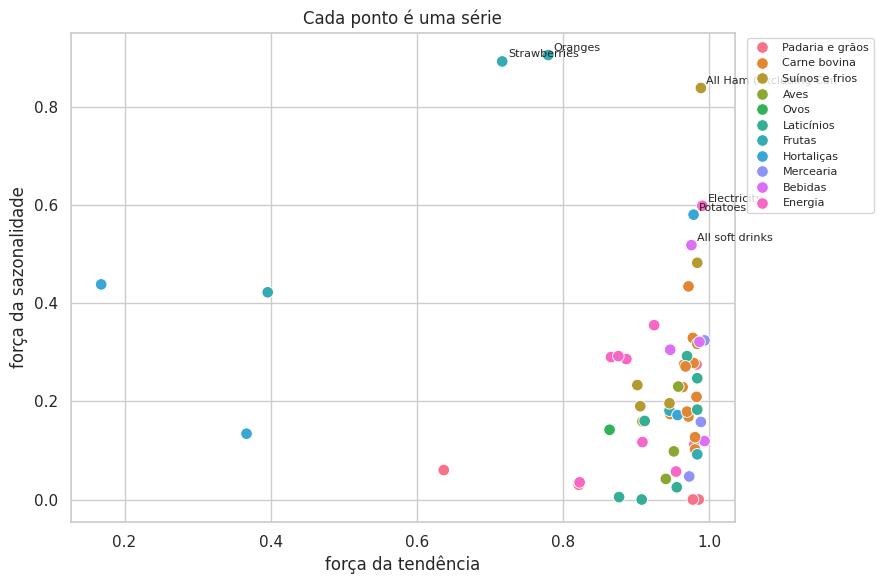

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=comp, x="forca_tendencia", y="forca_sazonalidade", hue="categoria", s=70, ax=ax)
for _, r in comp[comp["forca_sazonalidade"] > 0.5].iterrows():
    ax.annotate(r["item"].split(",")[0][:22], (r["forca_tendencia"], r["forca_sazonalidade"]), fontsize=8, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("força da tendência")
ax.set_ylabel("força da sazonalidade")
ax.set_title("Cada ponto é uma série")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_forcas.png", dpi=120)

A tendência é forte na maioria das séries (mediana acima de 0,85 em 9 das 11 categorias; frutas e
hortaliças ficam abaixo porque o ruído e a sazonalidade pesam mais). Sazonalidade forte é exceção:
laranja, morango, presunto (mais caro de julho a outubro e mais barato em dezembro, provavelmente pelas
promoções de fim de ano) e energia elétrica (mais cara de junho a setembro). Padaria e aves
praticamente não têm.

Isso explica o resultado do notebook 04: onde há sazonalidade, modelos conseguem ganhar do ingênuo;
onde a série é "tendência + ruído", repetir o último preço é difícil de bater.

## 3. Estacionariedade

Uma série é estacionária quando média e variância não mudam com o tempo. A maioria dos modelos
clássicos exige isso. O teste ADF (Dickey-Fuller aumentado) tem como hipótese nula "a série **não** é
estacionária"; p < 0,05 rejeita.

In [6]:
print(f"Estacionárias no nível (log do preço): {(comp['adf_p_nivel'] < 0.05).mean():.0%}")
print(f"Estacionárias na 1ª diferença (variação mensal): {(comp['adf_p_diferenca'] < 0.05).mean():.0%}")

Estacionárias no nível (log do preço): 8%
Estacionárias na 1ª diferença (variação mensal): 87%


O preço em si quase nunca é estacionário (sobe ao longo dos anos). A **variação mês a mês** é, na
grande maioria. Por isso:

- o SARIMA usa `d=1` (trabalha na diferença) e `D=1` (diferença sazonal de 12 meses);
- o modelo de ML prevê a **variação** em 3 meses, não o preço.

## 4. Autocorrelação: o preço de hoje explica o de amanhã?

A ACF mostra a correlação da série com ela mesma defasada k meses. A PACF mostra a mesma coisa
descontando as defasagens intermediárias.

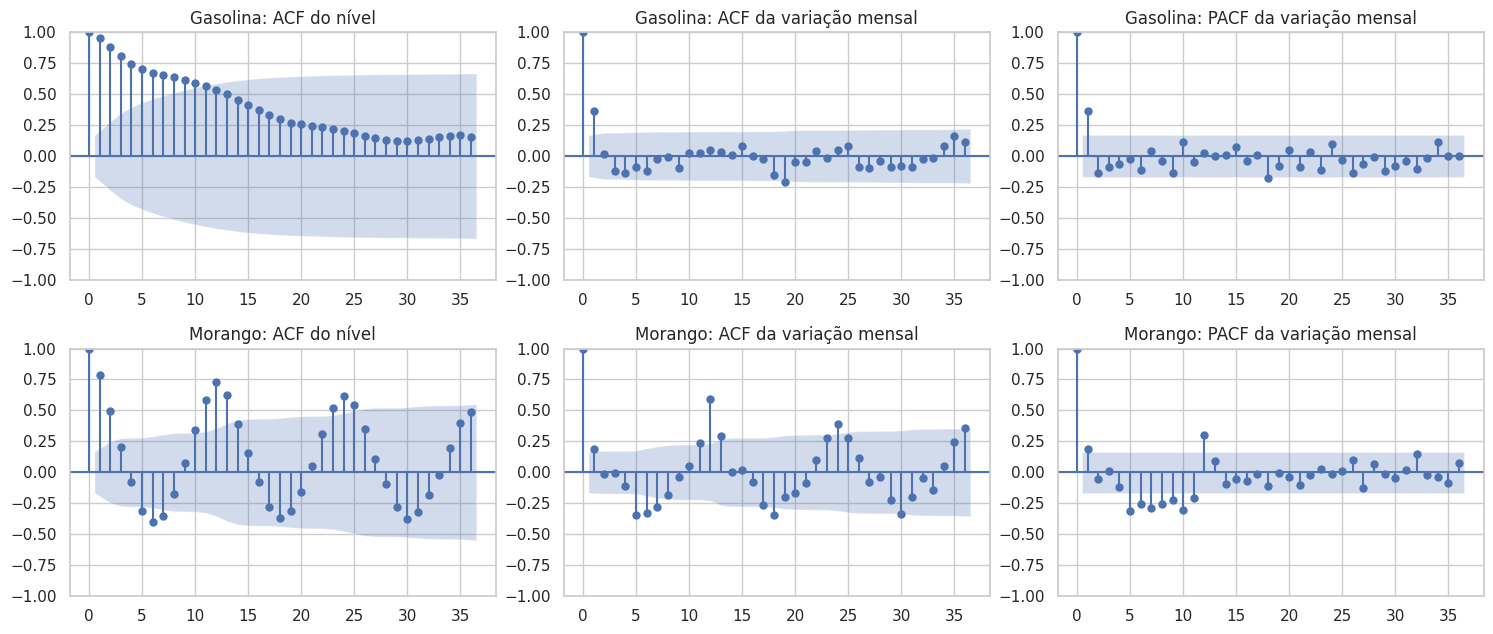

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 6.5))
gas = np.log(serie("Gasoline, unleaded regular")).dropna()
mor = np.log(serie("Strawberries")).interpolate(limit_area="inside").dropna()
plot_acf(gas, lags=36, ax=axes[0, 0], title="Gasolina: ACF do nível")
plot_acf(gas.diff().dropna(), lags=36, ax=axes[0, 1], title="Gasolina: ACF da variação mensal")
plot_pacf(gas.diff().dropna(), lags=36, ax=axes[0, 2], title="Gasolina: PACF da variação mensal", method="ywm")
plot_acf(mor, lags=36, ax=axes[1, 0], title="Morango: ACF do nível")
plot_acf(mor.diff().dropna(), lags=36, ax=axes[1, 1], title="Morango: ACF da variação mensal")
plot_pacf(mor.diff().dropna(), lags=36, ax=axes[1, 2], title="Morango: PACF da variação mensal", method="ywm")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_acf_pacf.png", dpi=120)

- **No nível da gasolina**, a correlação com o mês anterior é 0,95 e cai devagar: o preço de hoje é o
  melhor resumo do preço de amanhã. É por isso que o modelo ingênuo é tão forte. No morango o nível já
  oscila com o ciclo anual (positivo em 12 e 24, negativo perto de 6).
- **Na variação da gasolina**, há correlação positiva no lag 1 (uma alta costuma ser seguida de outra
  alta) e pouca coisa depois: é o termo autorregressivo AR(1).
- **Na variação do morango**, aparecem picos em 12 e 24 meses e valores negativos perto de 6 e 18: é a
  assinatura da sazonalidade anual. É esse padrão que o termo sazonal do SARIMA `(0,1,1)12` captura.

## 5. Modelos clássicos contra ML

`src/models/series_temporais.py` ajusta um **SARIMA(1,1,1)(0,1,1)12** e um **Holt-Winters (ETS)** por
item, com o mesmo protocolo do ML (parâmetros estimados até o corte, previsão de 3 meses a partir de
cada mês-base do teste). Resultados do backtest (gerados em `src.models.evaluate`):

In [8]:
met = pd.read_csv(POWERBI_DIR / "metricas_modelos.csv")
tab = met.pivot(index="modelo", columns="corte", values="wape")
tab["media"] = tab.mean(axis=1)
tab.sort_values("media").round(2)

corte,2021-12-01,2022-12-01,2023-12-01,2024-12-01,media
modelo,,,,,
combinado,4.79,3.75,2.81,3.86,3.80
gradient_boosting,4.82,3.85,2.87,3.97,3.88
random_forest,4.98,3.84,2.96,3.92,3.92
ingenuo,4.97,3.90,3.16,4.38,4.10
sarima,5.26,3.96,3.17,4.12,4.13
ridge,5.28,4.14,3.08,4.32,4.21
ets,5.49,4.11,3.16,4.27,4.26
sazonal_ingenuo,6.37,6.14,4.29,5.07,5.47


In [9]:
cat = pd.read_csv(POWERBI_DIR / "metricas_por_categoria.csv").pivot(index="categoria", columns="modelo", values="wape")
cat[["ingenuo", "sarima", "ets", "gradient_boosting", "combinado"]].round(2)

modelo,ingenuo,sarima,ets,gradient_boosting,combinado
categoria,,,,,
Aves,1.18,1.55,1.48,1.19,1.34
Bebidas,1.72,1.69,1.76,2.18,1.88
Carne bovina,4.13,3.78,4.00,3.56,3.58
Energia,8.94,8.97,10.07,8.72,8.10
Frutas,6.78,3.95,3.49,3.76,3.67
Hortaliças,6.83,6.18,7.07,5.96,5.86
Laticínios,3.16,3.42,3.30,3.31,3.31
Mercearia,4.09,3.79,3.56,4.18,3.87
Ovos,24.13,23.02,22.04,20.13,19.65


Leitura:

- **Sozinhos, os clássicos empatam com o ingênuo** na média (SARIMA 4,13%, ETS 4,26%, ingênuo 4,10%).
  Ganham com folga em frutas (a sazonalidade que a seção 2 mostrou) e perdem em aves e laticínios.
- **O ML sozinho é melhor que os clássicos** (3,88%), porque aprende com as 60 séries ao mesmo tempo e usa
  informação de fora da série (categoria, gasolina).
- **A combinação dos dois (média das previsões de gradient boosting e SARIMA) é o melhor modelo: 3,80%,
  e ganha do ingênuo nos quatro cortes.** Os erros dos dois não são iguais: o SARIMA olha só o histórico
  do próprio item, o ML olha o padrão entre itens. Na média, um corrige parte do erro do outro.

Esse passou a ser o modelo final (`predict_model` escolhe automaticamente pelo menor WAPE médio).

## 6. Granularidade temporal: mensal, trimestral ou anual?

Se o objetivo fosse prever o **preço médio do próximo trimestre**, valeria a pena trabalhar direto com
dados trimestrais? Agregar reduz o ruído, mas também reduz o número de pontos e atrasa a informação.

Experimento, nas 60 séries, prevendo cada trimestre de 2023 a 2026:

- **mensal:** usa os dados até o último mês antes do trimestre e prevê os 3 meses seguintes (a média deles é a previsão do trimestre);
- **trimestral:** usa as médias trimestrais até o trimestre anterior e prevê 1 passo.

Nos dois casos: o ingênuo e um SARIMA (sazonalidade 12 no mensal, 4 no trimestral), parâmetros
estimados até dez/2022.

In [10]:
trimestral = agregar(precos[precos["serie_id"].isin(series_ok)], "QS")
anual = agregar(precos[precos["serie_id"].isin(series_ok)], "YS")
print("Pontos por série (mediana): mensal", precos[precos["serie_id"].isin(series_ok)].groupby("serie_id").size().median(),
      "| trimestral", trimestral.dropna().groupby("serie_id").size().median(),
      "| anual", anual.dropna().groupby("serie_id").size().median())

Pontos por série (mediana): mensal 139.0 | trimestral 46.0 | anual 11.0


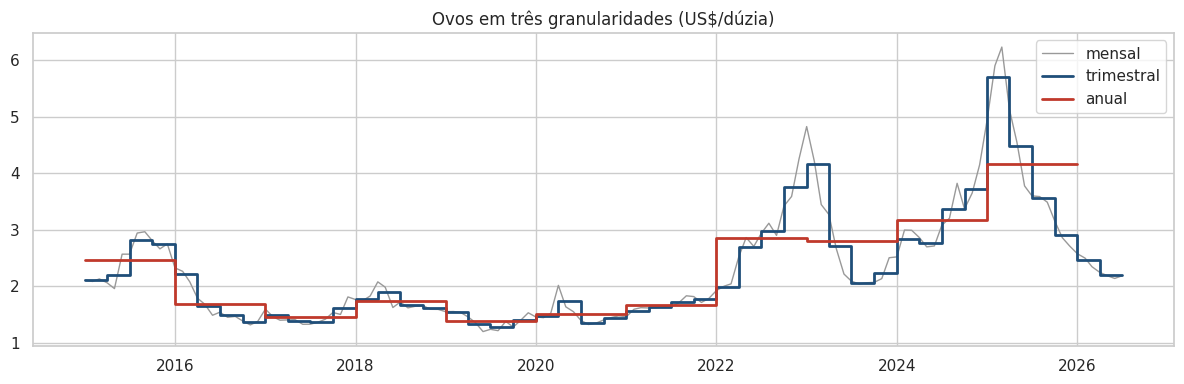

In [11]:
ovos_m = serie("Eggs")
sid_ovos = itens.loc[itens["item"].str.startswith("Eggs"), "serie_id"].iloc[0]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ovos_m, lw=1, color="#999", label="mensal")
for tab, cor, rot in [(trimestral, "#1f4e79", "trimestral"), (anual, "#c0392b", "anual")]:
    s = tab[tab["serie_id"] == sid_ovos].set_index("data")["preco"]
    ax.step(s.index, s.values, where="post", lw=2, color=cor, label=rot)
ax.set_title("Ovos em três granularidades (US$/dúzia)")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_granularidade_ovos.png", dpi=120)

In [12]:
CORTE_M, CORTE_Q = pd.Timestamp("2022-12-01"), pd.Timestamp("2022-10-01")
warnings.simplefilter("ignore")  # avisos de convergência do statsmodels em séries curtas
resultados = []
for sid in series_ok:
    ym = np.log(precos[precos["serie_id"] == sid].set_index("data")["preco"].asfreq("MS"))
    yq = np.log(trimestral[trimestral["serie_id"] == sid].set_index("data")["preco"].asfreq("QS"))
    ajuste_m = SARIMAX(ym[ym.index <= CORTE_M], order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
    ajuste_q = SARIMAX(yq[yq.index <= CORTE_Q], order=(1, 1, 1), seasonal_order=(0, 1, 1, 4)).fit(disp=False)
    for tri in pd.date_range("2023-01-01", "2026-04-01", freq="QS"):
        ultimo_mes, tri_anterior = tri - pd.DateOffset(months=1), tri - pd.DateOffset(months=3)
        if np.isnan(yq.get(tri, np.nan)) or np.isnan(ym.get(ultimo_mes, np.nan)) or np.isnan(yq.get(tri_anterior, np.nan)):
            continue
        prev_m = np.exp(ajuste_m.apply(ym[ym.index <= ultimo_mes]).forecast(3)).mean()
        prev_q = np.exp(ajuste_q.apply(yq[yq.index <= tri_anterior]).forecast(1).iloc[0])
        resultados.append({"serie_id": sid, "trimestre": tri, "real": np.exp(yq[tri]),
                           "ingenuo_mensal": np.exp(ym[ultimo_mes]), "sarima_mensal": prev_m,
                           "ingenuo_trimestral": np.exp(yq[tri_anterior]), "sarima_trimestral": prev_q})
gran = pd.DataFrame(resultados)
wape = {c: (gran[c] - gran["real"]).abs().sum() / gran["real"].sum() * 100
        for c in ["ingenuo_mensal", "sarima_mensal", "ingenuo_trimestral", "sarima_trimestral"]}
print(len(gran), "previsões de trimestre")
pd.Series(wape, name="WAPE (%)").round(2)

835 previsões de trimestre


ingenuo_mensal        2.74
sarima_mensal         2.64
ingenuo_trimestral    3.31
sarima_trimestral     3.27
Name: WAPE (%), dtype: float64

**Dados mensais preveem melhor até o trimestre.** Mesmo o ingênuo mensal (repetir o último mês) erra
menos que o SARIMA trimestral. O motivo é informação: no fim de março, o dado mensal já sabe o preço de
março; a média trimestral mistura janeiro, fevereiro e março e fica "atrasada" em mais de um mês.
Além disso, o trimestral tem só ~46 pontos por série para estimar um modelo sazonal.

No anual sobram cerca de 11 pontos por série: não dá para estimar um modelo com sazonalidade nem
validar com alguma segurança. **Conclusão: manter a granularidade mensal**, que é a mais fina disponível;
agregar só para apresentar (o dashboard pode mostrar médias trimestrais sem mudar o modelo).

## 7. Granularidade de produto: item específico ou agregado?

A base tem séries "All ..." que agregam itens parecidos. Comparamos volatilidade e erro de previsão
(teste principal) de cada agregado com os itens que ele resume.

In [13]:
grupos = {
    "Carne moída": ["APU0000FC1101", "APU0000703111", "APU0000703112", "APU0000703113"],
    "Bifes": ["APU0000FC3101", "APU0000703613", "APU0000703511"],
    "Costeletas suínas": ["APU0000FD3101", "APU0000704211", "APU0000704212"],
    "Presunto": ["APU0000FD2101", "APU0000704312"],
}
por_item = pd.read_csv(POWERBI_DIR / "metricas_por_item.csv").pivot(index="serie_id", columns="modelo", values="wape")
dim = pd.read_csv(POWERBI_DIR / "dim_item.csv").set_index("serie_id")
linhas = []
for grupo, ids in grupos.items():
    for sid in ids:
        linhas.append({"grupo": grupo, "item": dim.loc[sid, "item"][:40], "agregado": dim.loc[sid, "serie_agregada"],
                       "vol_mensal_%": dim.loc[sid, "vol_mensal_pct"], "wape_ingenuo": por_item.loc[sid, "ingenuo"],
                       "wape_combinado": por_item.loc[sid, "combinado"]})
pd.DataFrame(linhas).round(2)

,grupo,item,agregado,vol_mensal_%,wape_ingenuo,wape_combinado
0,Carne moída,All uncooked ground beef,True,1.76,3.30,2.44
1,Carne moída,"Ground chuck, 100% beef",False,2.79,3.87,3.21
2,Carne moída,"Ground beef, 100% beef",False,2.16,3.32,2.81
3,Carne moída,"Ground beef, lean and extra lean",False,2.14,3.58,2.86
4,Bifes,All Uncooked Beef Steaks,True,2.15,3.23,2.94
5,Bifes,"Steak, sirloin, USDA Choice, boneless",False,2.83,4.85,3.99
6,Bifes,"Steak, round, USDA Choice, boneless",False,2.48,3.68,4.16
7,Costeletas suínas,All Pork Chops,True,2.38,2.28,2.22
8,Costeletas suínas,"Chops, center cut, bone-in",False,3.29,2.56,1.97
9,Costeletas suínas,"Chops, boneless",False,2.71,2.80,2.32


Na maioria dos grupos a série agregada é **menos volátil** e **mais fácil de prever** que os itens
específicos: variações de marca, corte e embalagem se compensam na média. A exceção é o presunto, em
que a série agregada é mais sazonal que o presunto sem osso (seção 2) e, por isso, mais volátil; mesmo
assim é a que o modelo combinado prevê melhor, justamente por ser um padrão que se repete.

Para o projeto isso significa: prever no nível de item é o mais útil (é o que o consumidor compra),
mas quem precisa de uma previsão mais estável pode usar a série agregada ou a mediana da categoria.

## 8. Resumo

| Pergunta | Resposta |
|---|---|
| Do que as séries são feitas? | Quase todas: tendência forte e pouca sazonalidade. Sazonais: frutas, presunto, energia elétrica. |
| Estacionárias? | O preço não (8%); a variação mensal sim (87%). Por isso modelamos variação. |
| O preço de hoje explica o de amanhã? | Muito (ACF de 0,95 no 1º lag da gasolina). Daí a força do modelo ingênuo. |
| SARIMA/ETS funcionam? | Sozinhos empatam com o ingênuo; combinados com o ML formam o melhor modelo (3,80%). |
| Granularidade temporal | Mensal. Prevê melhor até o trimestre; anual não tem pontos suficientes. |
| Granularidade de produto | Item específico é o foco; agregados são mais estáveis e servem de referência. |